# Step 1:  Importing necessary libraries 

In [1]:
import pandas as pd
import numpy as np

# STEP 2: LOAD DATASET

In [2]:
df = pd.read_csv("Raw_Data.csv")
df.head()

,Ã¯Â»Â¿ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),Load_Date,Source_System
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,CÃÂ´te d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN,1/17/2026,Kaggle_SCMS
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN,NaN,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,CÃÂ´te d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN,NaN,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN,NaN,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN,NaN,NaN


In [3]:
df.columns

Index(['Ã¯Â»Â¿ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)', 'Load_Date', 'Source_System'],
      dtype='object')

In [4]:
# cleaning column names - standardize

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
df.columns= df.columns.str.replace("ã¯â»â¿id","id")
df.columns

Index(['id', 'project_code', 'pq_#', 'po___so_#', 'asn_dn_#', 'country',
       'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode',
       'pq_first_sent_to_client_date', 'po_sent_to_vendor_date',
       'scheduled_delivery_date', 'delivered_to_client_date',
       'delivery_recorded_date', 'product_group', 'sub_classification',
       'vendor', 'item_description', 'molecule_test_type', 'brand', 'dosage',
       'dosage_form', 'unit_of_measure_per_pack', 'line_item_quantity',
       'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_kilograms', 'freight_cost_usd',
       'line_item_insurance_usd', 'load_date', 'source_system'],
      dtype='object')

In [5]:
# dropping purely administrative/ tracking/ id-like columns
df= df.drop(
    columns=[
         "pq_#",
    "po___so_#",
    "asn_dn_#",
    "project_code",
    "managed_by",
    "delivery_recorded_date",
    "load_date",
    "source_system",
    "item_description"
    ], errors="ignore"
)
df.columns

Index(['id', 'country', 'fulfill_via', 'vendor_inco_term', 'shipment_mode',
       'pq_first_sent_to_client_date', 'po_sent_to_vendor_date',
       'scheduled_delivery_date', 'delivered_to_client_date', 'product_group',
       'sub_classification', 'vendor', 'molecule_test_type', 'brand', 'dosage',
       'dosage_form', 'unit_of_measure_per_pack', 'line_item_quantity',
       'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_kilograms', 'freight_cost_usd',
       'line_item_insurance_usd'],
      dtype='object')

Here we have removed delivery_recorded_date because it can leak delay info.

In [6]:
# final features for ML models
features= [
     "country",
    "shipment_mode",
    "vendor",
    "manufacturing_site",
    "vendor_inco_term",
    "line_item_quantity",
    "line_item_value",
    "pack_price",
    "unit_price",
    "weight_kilograms",
    "product_group",
    "sub_classification",
    "scheduled_delivery_date",
    "delivered_to_client_date",
    "pq_first_sent_to_client_date",
    "po_sent_to_vendor_date",
    "freight_cost_usd",
    "line_item_insurance_usd"
]
df = df[[col for col in features if col in df.columns]]
df.head()

,country,shipment_mode,vendor,manufacturing_site,vendor_inco_term,line_item_quantity,line_item_value,pack_price,unit_price,weight_kilograms,product_group,sub_classification,scheduled_delivery_date,delivered_to_client_date,pq_first_sent_to_client_date,po_sent_to_vendor_date,freight_cost_usd,line_item_insurance_usd
0,CÃÂ´te d'Ivoire,Air,RANBAXY Fine Chemicals LTD.,Ranbaxy Fine Chemicals LTD,EXW,19,551.0,29.00,0.97,13,HRDT,HIV test,2-Jun-06,2-Jun-06,Pre-PQ Process,Date Not Captured,780.34,NaN
1,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,1000,6200.0,6.20,0.03,358,ARV,Pediatric,14-Nov-06,14-Nov-06,Pre-PQ Process,Date Not Captured,4521.5,NaN
2,CÃÂ´te d'Ivoire,Air,Abbott GmbH & Co. KG,ABBVIE GmbH & Co.KG Wiesbaden,FCA,500,40000.0,80.00,0.80,171,HRDT,HIV test,27-Aug-06,27-Aug-06,Pre-PQ Process,Date Not Captured,1653.78,NaN
3,Vietnam,Air,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Ranbaxy, Paonta Shahib, India",EXW,31920,127360.8,3.99,0.07,1855,ARV,Adult,1-Sep-06,1-Sep-06,Pre-PQ Process,Date Not Captured,16007.06,NaN
4,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,38000,121600.0,3.20,0.05,7590,ARV,Adult,11-Aug-06,11-Aug-06,Pre-PQ Process,Date Not Captured,45450.08,NaN


# STEP 3: DATA CLEANING

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       10324 non-null  object 
 1   shipment_mode                 9964 non-null   object 
 2   vendor                        10324 non-null  object 
 3   manufacturing_site            10324 non-null  object 
 4   vendor_inco_term              10324 non-null  object 
 5   line_item_quantity            10324 non-null  int64  
 6   line_item_value               10324 non-null  float64
 7   pack_price                    10324 non-null  float64
 8   unit_price                    10324 non-null  float64
 9   weight_kilograms              10324 non-null  object 
 10  product_group                 10324 non-null  object 
 11  sub_classification            10324 non-null  object 
 12  scheduled_delivery_date       10324 non-null  object 
 13  d

In [8]:
df_clean=df.copy()
df_clean.head()

,country,shipment_mode,vendor,manufacturing_site,vendor_inco_term,line_item_quantity,line_item_value,pack_price,unit_price,weight_kilograms,product_group,sub_classification,scheduled_delivery_date,delivered_to_client_date,pq_first_sent_to_client_date,po_sent_to_vendor_date,freight_cost_usd,line_item_insurance_usd
0,CÃÂ´te d'Ivoire,Air,RANBAXY Fine Chemicals LTD.,Ranbaxy Fine Chemicals LTD,EXW,19,551.0,29.00,0.97,13,HRDT,HIV test,2-Jun-06,2-Jun-06,Pre-PQ Process,Date Not Captured,780.34,NaN
1,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,1000,6200.0,6.20,0.03,358,ARV,Pediatric,14-Nov-06,14-Nov-06,Pre-PQ Process,Date Not Captured,4521.5,NaN
2,CÃÂ´te d'Ivoire,Air,Abbott GmbH & Co. KG,ABBVIE GmbH & Co.KG Wiesbaden,FCA,500,40000.0,80.00,0.80,171,HRDT,HIV test,27-Aug-06,27-Aug-06,Pre-PQ Process,Date Not Captured,1653.78,NaN
3,Vietnam,Air,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Ranbaxy, Paonta Shahib, India",EXW,31920,127360.8,3.99,0.07,1855,ARV,Adult,1-Sep-06,1-Sep-06,Pre-PQ Process,Date Not Captured,16007.06,NaN
4,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,38000,121600.0,3.20,0.05,7590,ARV,Adult,11-Aug-06,11-Aug-06,Pre-PQ Process,Date Not Captured,45450.08,NaN


In [9]:
# Convert freight_cost_usd to numeric (errors → NaN)
df_clean["freight_cost_usd"] = pd.to_numeric(df_clean["freight_cost_usd"], errors="coerce")

# Check missing after conversion
df_clean["freight_cost_usd"].isnull().sum()

4126

In [10]:
# drop rows where target (freight_cost_usd) is missing
df_clean = df_clean.dropna(subset=["freight_cost_usd"])
df_clean.shape

(6198, 18)

Removed records with missing target variable to ensure model reliability and prevent bias in training data.

In [11]:
df_clean.isnull().sum().sort_values(ascending=False)

shipment_mode                   211
line_item_insurance_usd         192
freight_cost_usd                  0
po_sent_to_vendor_date            0
pq_first_sent_to_client_date      0
delivered_to_client_date          0
scheduled_delivery_date           0
sub_classification                0
product_group                     0
country                           0
unit_price                        0
pack_price                        0
line_item_value                   0
line_item_quantity                0
vendor_inco_term                  0
manufacturing_site                0
vendor                            0
weight_kilograms                  0
dtype: int64

In [12]:
# filling the missing values: 
most_common_mode = df_clean["shipment_mode"].mode()[0]
df_clean["shipment_mode"]=df_clean["shipment_mode"].fillna(most_common_mode)


In [13]:
#removing commas
df_clean["line_item_insurance_usd"] =df_clean["line_item_insurance_usd"].str.replace(",","")
df_clean["line_item_insurance_usd"]= pd.to_numeric(df["line_item_insurance_usd"], errors="coerce")

median_insurance = df_clean["line_item_insurance_usd"].median()
df_clean["line_item_insurance_usd"]=df_clean["line_item_insurance_usd"].fillna(median_insurance)

df_clean.isnull().sum()

country                         0
shipment_mode                   0
vendor                          0
manufacturing_site              0
vendor_inco_term                0
line_item_quantity              0
line_item_value                 0
pack_price                      0
unit_price                      0
weight_kilograms                0
product_group                   0
sub_classification              0
scheduled_delivery_date         0
delivered_to_client_date        0
pq_first_sent_to_client_date    0
po_sent_to_vendor_date          0
freight_cost_usd                0
line_item_insurance_usd         0
dtype: int64

In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6198 entries, 0 to 10316
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       6198 non-null   object 
 1   shipment_mode                 6198 non-null   object 
 2   vendor                        6198 non-null   object 
 3   manufacturing_site            6198 non-null   object 
 4   vendor_inco_term              6198 non-null   object 
 5   line_item_quantity            6198 non-null   int64  
 6   line_item_value               6198 non-null   float64
 7   pack_price                    6198 non-null   float64
 8   unit_price                    6198 non-null   float64
 9   weight_kilograms              6198 non-null   object 
 10  product_group                 6198 non-null   object 
 11  sub_classification            6198 non-null   object 
 12  scheduled_delivery_date       6198 non-null   object 
 13  deliver

In [15]:
# converting the dates which are in strings to date-time values
date_cols = [
    "scheduled_delivery_date",
    "delivered_to_client_date",
    "pq_first_sent_to_client_date",
    "po_sent_to_vendor_date"
]

for col in date_cols:
    df_clean[col]=pd.to_datetime(df_clean[col], errors="coerce", dayfirst=True)

/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_34253/3782557100.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col]=pd.to_datetime(df_clean[col], errors="coerce", dayfirst=True)
/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_34253/3782557100.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col]=pd.to_datetime(df_clean[col], errors="coerce", dayfirst=True)
/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_34253/3782557100.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col]=pd.to_datetime(df_clean[col

In [16]:
df_clean[date_cols].isnull().sum()

scheduled_delivery_date            0
delivered_to_client_date           0
pq_first_sent_to_client_date    1572
po_sent_to_vendor_date          3280
dtype: int64

In [17]:
df_clean["po_missing"]=df_clean["po_sent_to_vendor_date"].isnull().astype(int)
df_clean["pq_missing"]=df_clean["pq_first_sent_to_client_date"].isnull().astype(int)

Here, instead of losing information, we are keeping as data was missing.

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6198 entries, 0 to 10316
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       6198 non-null   object        
 1   shipment_mode                 6198 non-null   object        
 2   vendor                        6198 non-null   object        
 3   manufacturing_site            6198 non-null   object        
 4   vendor_inco_term              6198 non-null   object        
 5   line_item_quantity            6198 non-null   int64         
 6   line_item_value               6198 non-null   float64       
 7   pack_price                    6198 non-null   float64       
 8   unit_price                    6198 non-null   float64       
 9   weight_kilograms              6198 non-null   object        
 10  product_group                 6198 non-null   object        
 11  sub_classification            6198

In [19]:
df_clean.head()

,country,shipment_mode,vendor,manufacturing_site,vendor_inco_term,line_item_quantity,line_item_value,pack_price,unit_price,weight_kilograms,product_group,sub_classification,scheduled_delivery_date,delivered_to_client_date,pq_first_sent_to_client_date,po_sent_to_vendor_date,freight_cost_usd,line_item_insurance_usd,po_missing,pq_missing
0,CÃÂ´te d'Ivoire,Air,RANBAXY Fine Chemicals LTD.,Ranbaxy Fine Chemicals LTD,EXW,19,551.0,29.00,0.97,13,HRDT,HIV test,2006-06-02,2006-06-02,NaT,NaT,780.34,72.56,1,1
1,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,1000,6200.0,6.20,0.03,358,ARV,Pediatric,2006-11-14,2006-11-14,NaT,NaT,4521.50,72.56,1,1
2,CÃÂ´te d'Ivoire,Air,Abbott GmbH & Co. KG,ABBVIE GmbH & Co.KG Wiesbaden,FCA,500,40000.0,80.00,0.80,171,HRDT,HIV test,2006-08-27,2006-08-27,NaT,NaT,1653.78,72.56,1,1
3,Vietnam,Air,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Ranbaxy, Paonta Shahib, India",EXW,31920,127360.8,3.99,0.07,1855,ARV,Adult,2006-09-01,2006-09-01,NaT,NaT,16007.06,72.56,1,1
4,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,38000,121600.0,3.20,0.05,7590,ARV,Adult,2006-08-11,2006-08-11,NaT,NaT,45450.08,72.56,1,1


In [20]:
# converting weight_kilograms to numeric
df_clean["weight_kilograms"]=df_clean["weight_kilograms"].str.replace(",","")
df_clean["weight_kilograms"]=pd.to_numeric(
    df_clean["weight_kilograms"], errors="coerce"
)

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6198 entries, 0 to 10316
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       6198 non-null   object        
 1   shipment_mode                 6198 non-null   object        
 2   vendor                        6198 non-null   object        
 3   manufacturing_site            6198 non-null   object        
 4   vendor_inco_term              6198 non-null   object        
 5   line_item_quantity            6198 non-null   int64         
 6   line_item_value               6198 non-null   float64       
 7   pack_price                    6198 non-null   float64       
 8   unit_price                    6198 non-null   float64       
 9   weight_kilograms              6175 non-null   float64       
 10  product_group                 6198 non-null   object        
 11  sub_classification            6198

In [22]:
df_clean["country"] = df_clean["country"].str.replace("CÃ´te d'Ivoire", "Côte d'Ivoire")

In [23]:
df_clean["country"]

0        CÃÂ´te d'Ivoire
1                 Vietnam
2        CÃÂ´te d'Ivoire
3                 Vietnam
4                 Vietnam
               ...       
10305          Mozambique
10306          Mozambique
10310              Uganda
10315             Nigeria
10316             Nigeria
Name: country, Length: 6198, dtype: object

In [24]:
# checking duplicates
df_clean["shipment_mode"].value_counts()

shipment_mode
Air            4326
Truck          1166
Air Charter     424
Ocean           282
Name: count, dtype: int64

In [25]:
df_clean.duplicated().sum()

25

In [26]:
df_clean.duplicated(subset=["vendor", "country", "shipment_mode", "line_item_quantity"]).sum()

706

In [27]:
df_clean[df_clean.duplicated(subset=["vendor", "country", "shipment_mode", "line_item_quantity"], keep=False)].head()

,country,shipment_mode,vendor,manufacturing_site,vendor_inco_term,line_item_quantity,line_item_value,pack_price,unit_price,weight_kilograms,product_group,sub_classification,scheduled_delivery_date,delivered_to_client_date,pq_first_sent_to_client_date,po_sent_to_vendor_date,freight_cost_usd,line_item_insurance_usd,po_missing,pq_missing
0,CÃÂ´te d'Ivoire,Air,RANBAXY Fine Chemicals LTD.,Ranbaxy Fine Chemicals LTD,EXW,19,551.0,29.00,0.97,13.0,HRDT,HIV test,2006-06-02,2006-06-02,NaT,NaT,780.34,72.56,1,1
1,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,1000,6200.0,6.20,0.03,358.0,ARV,Pediatric,2006-11-14,2006-11-14,NaT,NaT,4521.50,72.56,1,1
2,CÃÂ´te d'Ivoire,Air,Abbott GmbH & Co. KG,ABBVIE GmbH & Co.KG Wiesbaden,FCA,500,40000.0,80.00,0.80,171.0,HRDT,HIV test,2006-08-27,2006-08-27,NaT,NaT,1653.78,72.56,1,1
17,Rwanda,Air,Premier Medical Corporation Ltd.,Premier Med. Corp Ltd. India,EXW,2000,33000.0,16.50,0.55,710.0,HRDT,HIV test,2007-03-29,2007-03-29,NaT,NaT,3120.70,72.56,1,1
22,Vietnam,Air,Aurobindo Pharma Limited,"Aurobindo Unit III, India",EXW,1000,1920.0,1.92,0.01,941.0,ARV,Pediatric,2007-10-15,2007-10-15,NaT,2007-04-07,4193.49,3.07,0,1


Since they have different dates, Those 706 rows are probably:
-repeat orders
-recurring shipments
-normal business behavior

In [28]:
df_clean.duplicated().sum()

25

In [29]:
df_clean = df_clean.drop_duplicates()

In [30]:
df_clean.duplicated().sum()

0

Data cleaning completed: handled missing values, fixed data types (numeric & datetime), cleaned categorical text issues, and removed exact duplicates.
Dataset is now consistent, structured, and ready for feature engineering and machine learning.

# STEP 4: Feature Engineering

In [31]:
# - calculate delivery delay
df_clean["delivery_delay"]=(
    df_clean["delivered_to_client_date"] - df_clean["scheduled_delivery_date"]
).dt.days

# - processing time
df_clean["processing_time"] = (
    df_clean["delivered_to_client_date"] - df_clean["po_sent_to_vendor_date"]
).dt.days

# -cost per kg
df_clean["cost_per_kg"]=(
    df_clean["freight_cost_usd"] / df_clean["weight_kilograms"]
)

Created new features to improve ML model understanding:
- delivery_delay: measures shipment delay in days
- processing_time: time from order to delivery
- cost_per_kg: normalized shipping cost

# STEP 4: Exploratory Data Analysis

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

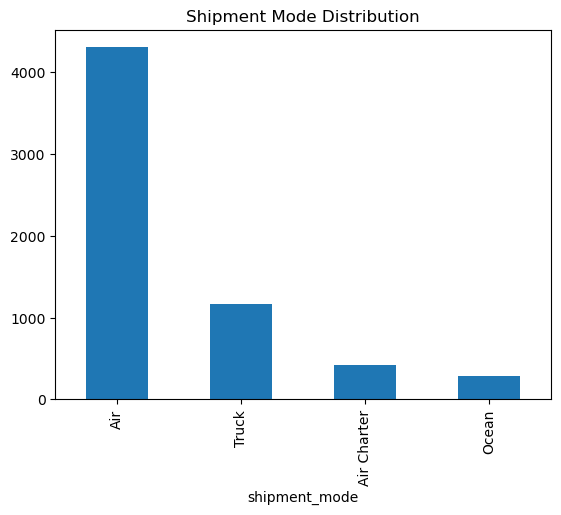

In [33]:
# univariate - categorical
df_clean["shipment_mode"].value_counts().plot(kind="bar")
plt.title("Shipment Mode Distribution")
plt.show()

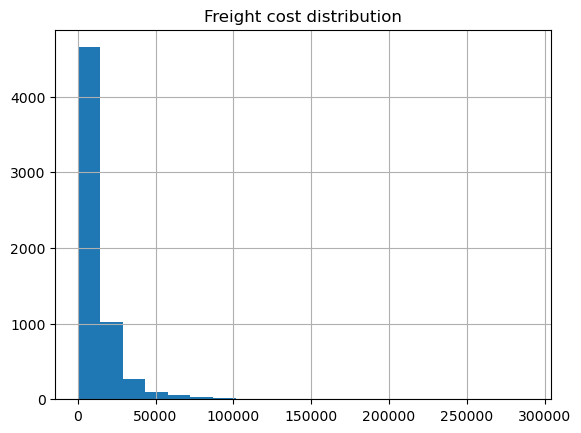

In [34]:
# univariate - numerical
df_clean["freight_cost_usd"].hist(bins=20)
plt.title("Freight cost distribution")
plt.show()

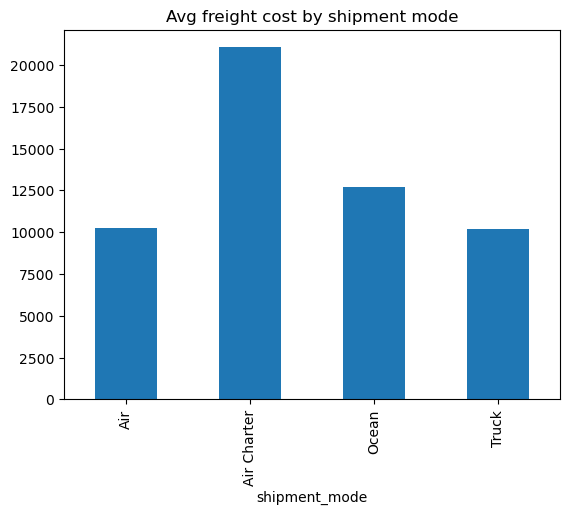

In [35]:
# bivariate analysis
df_clean.groupby("shipment_mode")["freight_cost_usd"].mean().plot(kind="bar")
plt.title("Avg freight cost by shipment mode")
plt.show()

Text(0, 0.5, 'freight cost')

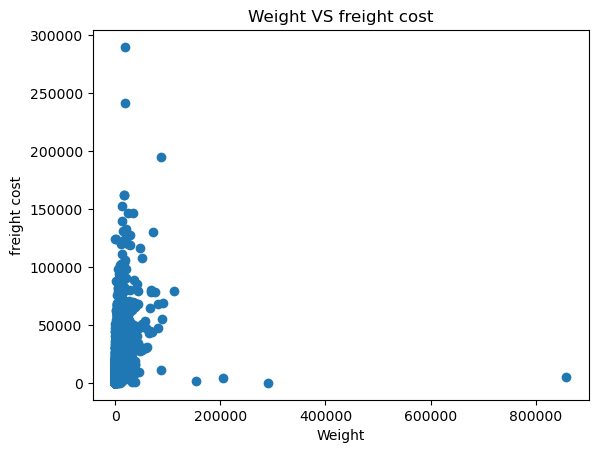

In [36]:
plt.scatter(df_clean["weight_kilograms"], df_clean["freight_cost_usd"])
plt.title("Weight VS freight cost")
plt.xlabel("Weight")
plt.ylabel("freight cost")

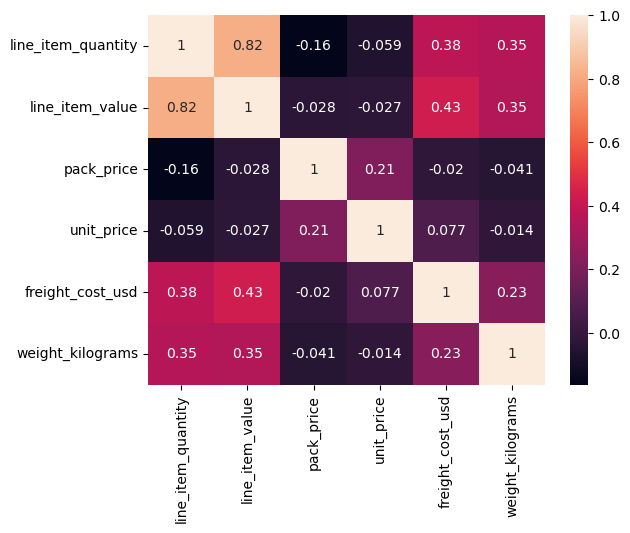

In [37]:
# muplivariate analysis
corr = df_clean[["line_item_quantity",
    "line_item_value",
    "pack_price",
    "unit_price",
    "freight_cost_usd",
    "weight_kilograms"]].corr()
sns.heatmap(corr,annot=True)
plt.show()

 Correlation checked: strong relation (0.82) between quantity and value, weak relation (-0.02) with freight cost. Kept features since using tree-based models (Random Forest, XGBoost).

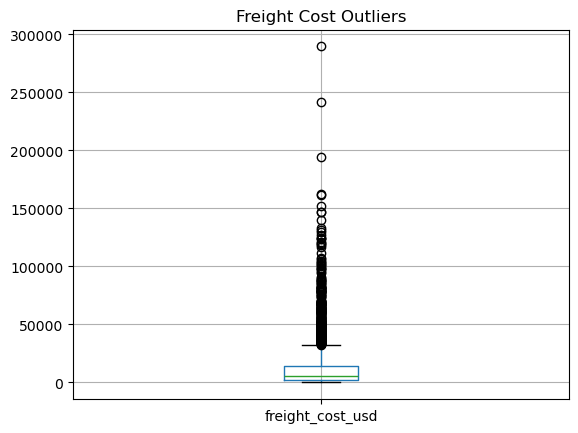

In [38]:
# outlier detection 
df_clean.boxplot(column="freight_cost_usd")
plt.title("Freight Cost Outliers")
plt.show()

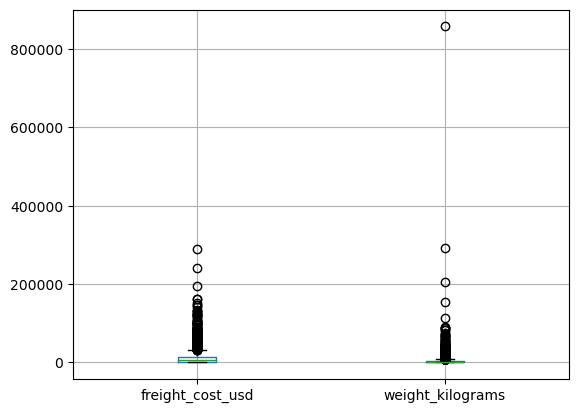

In [39]:
df_clean[["freight_cost_usd", "weight_kilograms"]].boxplot()
plt.show()

Outliers were retained as they represent valid real-world logistics shipments and will be handled using log transformation.

In [40]:
# transforming 
df_clean["freight_cost_log"] = np.log1p(df_clean["freight_cost_usd"])


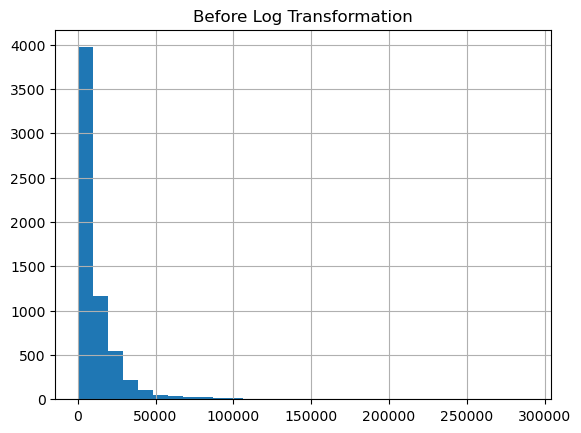

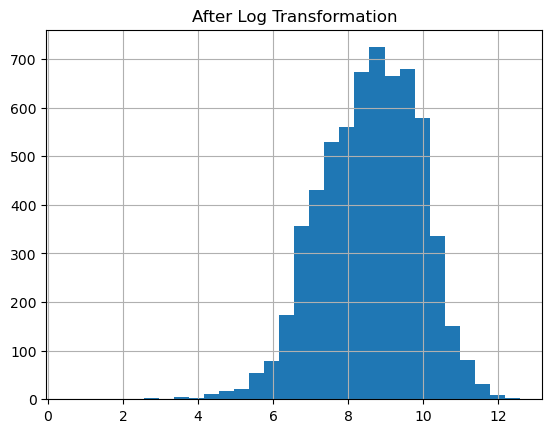

In [41]:
df_clean["freight_cost_usd"].hist(bins=30)
plt.title("Before Log Transformation")
plt.show()

df_clean["freight_cost_log"].hist(bins=30)
plt.title("After Log Transformation")
plt.show()

In [42]:
df_clean["freight_cost_log"].describe()

count    6173.000000
mean        8.582901
std         1.299969
min         0.559616
25%         7.661075
50%         8.675504
75%         9.569269
max        12.576443
Name: freight_cost_log, dtype: float64

Applied log transformation to freight_cost_usd to reduce skewness and lessen the impact of extreme values while preserving all observations.

In [43]:
df_clean["weight_kilograms"].describe()

count      6150.000000
mean       3437.730244
std       13690.596194
min           0.000000
25%         209.000000
50%        1051.000000
75%        3337.750000
max      857354.000000
Name: weight_kilograms, dtype: float64

In [44]:
# transforming weight too
df_clean["weight_log"]=np.log1p(df_clean["weight_kilograms"])

In [45]:
df_clean["weight_log"].describe()

count    6150.000000
mean        6.656785
std         1.990371
min         0.000000
25%         5.347108
50%         6.958448
75%         8.113352
max        13.661607
Name: weight_log, dtype: float64

Since these values represent valid business events rather than data errors, I retained them and applied log transformation to reduce skewness while preserving information."

In [46]:
#top countries by freight cost
df_clean.groupby("country")["freight_cost_usd"].mean().sort_values(ascending=False)

country
Cameroon              32006.276607
Nigeria               18619.180700
Sierra Leone          18249.265000
Rwanda                16624.248290
Kenya                 15703.424615
Zimbabwe              13536.052853
Pakistan              13298.476250
Ghana                 13162.594762
Zambia                12198.402539
Tanzania              11674.242634
Ethiopia              11541.574734
Haiti                 10102.270025
Uganda                 9723.922411
Benin                  9430.738571
Mozambique             9024.989205
Dominican Republic     8780.877857
South Africa           8628.329758
CÃÂ´te d'Ivoire       8380.898774
Swaziland              7995.490400
Guatemala              7698.996000
Malawi                 7172.866429
Congo, DRC             6782.140680
Togo                   6272.360000
Vietnam                6150.031242
Lesotho                5825.705000
Namibia                5747.992125
Burundi                5572.184286
Angola                 4685.242857
South Sudan 

<Axes: >

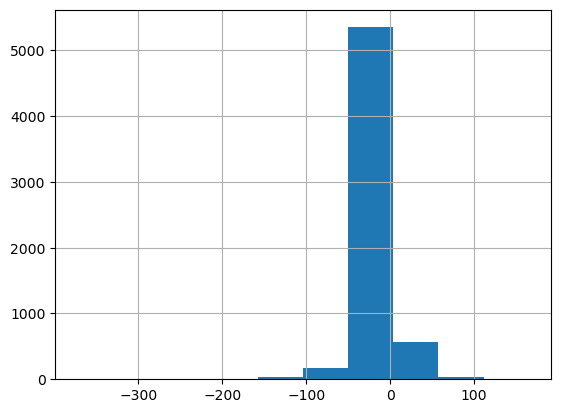

In [47]:
df_clean["delivery_delay"].hist()

Analyzed delivery delays and found that most shipments were delivered before the scheduled date (negative delay values), indicating generally efficient delivery performance.

# STEP 5: PREPARE DATA FOR MACHINE LEARNING

In [48]:
# Target variable selected: freight_cost_usd
# Objective is to predict shipment freight cost using logistics and shipment-related features.

# dropping raw-dates and target variable!
features_to_drop=[
      "freight_cost_usd",   # target
    "scheduled_delivery_date",
    "delivered_to_client_date",
    "pq_first_sent_to_client_date",
    "po_sent_to_vendor_date","freight_cost_log"
]

In [98]:
X = df_clean.drop(columns=features_to_drop)
y = df_clean["freight_cost_usd"]

In [99]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 10316
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  6173 non-null   object 
 1   shipment_mode            6173 non-null   object 
 2   vendor                   6173 non-null   object 
 3   manufacturing_site       6173 non-null   object 
 4   vendor_inco_term         6173 non-null   object 
 5   line_item_quantity       6173 non-null   int64  
 6   line_item_value          6173 non-null   float64
 7   pack_price               6173 non-null   float64
 8   unit_price               6173 non-null   float64
 9   weight_kilograms         6150 non-null   float64
 10  product_group            6173 non-null   object 
 11  sub_classification       6173 non-null   object 
 12  line_item_insurance_usd  6173 non-null   float64
 13  po_missing               6173 non-null   int64  
 14  pq_missing               617

In [100]:
X = X.drop(columns=["weight_kilograms"])

In [101]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 10316
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  6173 non-null   object 
 1   shipment_mode            6173 non-null   object 
 2   vendor                   6173 non-null   object 
 3   manufacturing_site       6173 non-null   object 
 4   vendor_inco_term         6173 non-null   object 
 5   line_item_quantity       6173 non-null   int64  
 6   line_item_value          6173 non-null   float64
 7   pack_price               6173 non-null   float64
 8   unit_price               6173 non-null   float64
 9   product_group            6173 non-null   object 
 10  sub_classification       6173 non-null   object 
 11  line_item_insurance_usd  6173 non-null   float64
 12  po_missing               6173 non-null   int64  
 13  pq_missing               6173 non-null   int64  
 14  delivery_delay           617

In [102]:
y.info()

<class 'pandas.core.series.Series'>
Index: 6173 entries, 0 to 10316
Series name: freight_cost_usd
Non-Null Count  Dtype  
--------------  -----  
6173 non-null   float64
dtypes: float64(1)
memory usage: 96.5 KB


In [103]:
# processing_time has alot missing values and it is alr partially represented by delivery_delay
X=X.drop(columns=["processing_time"])

In [104]:
# cost_per_kg and weight_log also has missing values so filling it w median

X["cost_per_kg"] = X["cost_per_kg"].fillna(X["cost_per_kg"].median())
X["weight_log"] = X["weight_log"].fillna(X["weight_log"].median())


In [105]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 10316
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  6173 non-null   object 
 1   shipment_mode            6173 non-null   object 
 2   vendor                   6173 non-null   object 
 3   manufacturing_site       6173 non-null   object 
 4   vendor_inco_term         6173 non-null   object 
 5   line_item_quantity       6173 non-null   int64  
 6   line_item_value          6173 non-null   float64
 7   pack_price               6173 non-null   float64
 8   unit_price               6173 non-null   float64
 9   product_group            6173 non-null   object 
 10  sub_classification       6173 non-null   object 
 11  line_item_insurance_usd  6173 non-null   float64
 12  po_missing               6173 non-null   int64  
 13  pq_missing               6173 non-null   int64  
 14  delivery_delay           617

# STEP 6: ENCODING

In [106]:
X.select_dtypes(include="object").columns

Index(['country', 'shipment_mode', 'vendor', 'manufacturing_site',
       'vendor_inco_term', 'product_group', 'sub_classification'],
      dtype='object')

In [107]:
from sklearn.preprocessing import OneHotEncoder

In [108]:
small_cat_col=[
    "shipment_mode",
    "vendor_inco_term",
    "product_group",
    "sub_classification"
]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = ohe.fit_transform(X[small_cat_col])

In [109]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(small_cat_col),
    index=X.index
)

In [110]:
X= X.drop(columns=small_cat_col)
X=pd.concat([X,encoded_df],axis=1)

Applied One-Hot Encoding to low-cardinality categorical variables to convert them into numerical format for ML models.

In [111]:
X.shape
X.head()

,country,vendor,manufacturing_site,line_item_quantity,line_item_value,pack_price,unit_price,line_item_insurance_usd,po_missing,pq_missing,...,product_group_ANTM,product_group_ARV,product_group_HRDT,product_group_MRDT,sub_classification_ACT,sub_classification_Adult,sub_classification_HIV test,sub_classification_HIV test - Ancillary,sub_classification_Malaria,sub_classification_Pediatric
0,CÃÂ´te d'Ivoire,RANBAXY Fine Chemicals LTD.,Ranbaxy Fine Chemicals LTD,19,551.0,29.00,0.97,72.56,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Vietnam,Aurobindo Pharma Limited,"Aurobindo Unit III, India",1000,6200.0,6.20,0.03,72.56,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CÃÂ´te d'Ivoire,Abbott GmbH & Co. KG,ABBVIE GmbH & Co.KG Wiesbaden,500,40000.0,80.00,0.80,72.56,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Ranbaxy, Paonta Shahib, India",31920,127360.8,3.99,0.07,72.56,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Vietnam,Aurobindo Pharma Limited,"Aurobindo Unit III, India",38000,121600.0,3.20,0.05,72.56,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [112]:
# applying frequency encoding for large category columns

country_freq = X["country"].value_counts()
X["country_freq"] = X["country"].map(country_freq)

vendor_freq = X["vendor"].value_counts()
X["vendor_freq"] =X["vendor"].map(vendor_freq)

site_freq = X['manufacturing_site'].value_counts()
X['site_freq']=X['manufacturing_site'].map(site_freq)

In [113]:
X=X.drop(columns = ["country", "vendor", "manufacturing_site"])

Applied frequency encoding to high-cardinality categorical features to convert them into numerical format while avoiding dimensional explosion from one-hot encoding.

In [114]:
import numpy as np

np.isinf(X).sum()

line_item_quantity                         0
line_item_value                            0
pack_price                                 0
unit_price                                 0
line_item_insurance_usd                    0
po_missing                                 0
pq_missing                                 0
delivery_delay                             0
cost_per_kg                                1
weight_log                                 0
shipment_mode_Air                          0
shipment_mode_Air Charter                  0
shipment_mode_Ocean                        0
shipment_mode_Truck                        0
vendor_inco_term_CIF                       0
vendor_inco_term_CIP                       0
vendor_inco_term_DAP                       0
vendor_inco_term_DDP                       0
vendor_inco_term_DDU                       0
vendor_inco_term_EXW                       0
vendor_inco_term_FCA                       0
vendor_inco_term_N/A - From RDC            0
product_gr

In [115]:
X["cost_per_kg"] = X["cost_per_kg"].fillna(X["cost_per_kg"].median())

In [116]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# STEP 7: RANDOM FOREST MODEL (FIRST MODEL)

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [118]:
from sklearn.ensemble import RandomForestRegressor

model_rf= RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [119]:
y_pred = model_rf.predict(X_test)

In [120]:
# evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae= mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test,y_pred) ** 0.5

print("Mae : ",mae)
print("Rmse : ",rmse)

Mae :  618.0591107692309
Rmse :  2969.334395215503


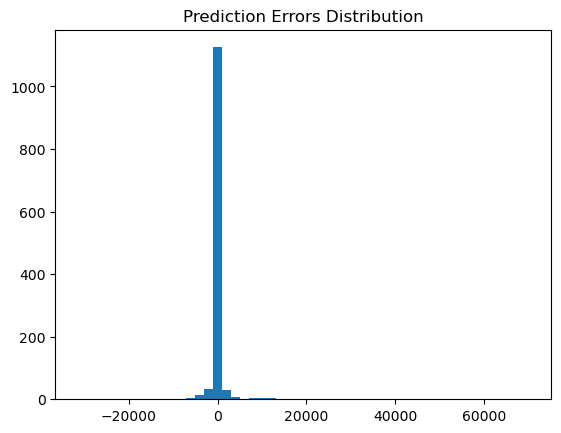

In [121]:
import matplotlib.pyplot as plt

errors = y_test - y_pred

plt.hist(errors, bins=50)
plt.title("Prediction Errors Distribution")
plt.show()

In [122]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9676087249650698


In [123]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape)

MAPE: 0.08636000109029573


In [124]:
# applying log transformation
y_train_log=np.log1p(y_train)
y_test_log=np.log1p(y_test)

Applied log transformation to the target variable to reduce skewness and minimize the impact of extreme outliers in freight cost distribution.

# Train Random Forest on log data

In [125]:
model_rf2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model_rf2.fit(X_train, y_train_log)


RandomForestRegressor(random_state=42)

In [126]:
y_pred_log = model_rf2.predict(X_test)

In [127]:
y_pred=np.expm1(y_pred_log)

In [128]:
# evaluating
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 555.3473945921041
RMSE: 2743.1123350715243
R2: 0.9723562464858023


Since the baseline Random Forest model already performed strongly, applying log transformation provided marginal improvements by reducing the impact of extreme values and stabilizing error distribution

# Get feature importance (Random Forest) 

In [129]:
feature_importance = pd.DataFrame(
    {
        "Feature":X_train.columns,
        "Importance":model_rf2.feature_importances_
    }).sort_values(by="Importance", ascending=False)
feature_importance.head(5)

,Feature,Importance
9,weight_log,0.692131
8,cost_per_kg,0.277167
11,shipment_mode_Air Charter,0.011885
0,line_item_quantity,0.004625
1,line_item_value,0.004079


Random Forest feature importance analysis reveals that weight_log (65%) and cost_per_kg (30%) are the primary drivers of freight cost,
 while other features contribute marginally, highlighting that shipment weight and cost density are the key determinants of shipping expenses.

In [130]:
# saving the trained model 
import joblib
joblib.dump(model_rf2, "freight_cost_model.pkl")

['freight_cost_model.pkl']

In [131]:
model_features=X_train.columns
joblib.dump(model_features,"model_features.pkl")

['model_features.pkl']

In [132]:
# loading the saved model 
import pickle

model=pickle.load(open("freight_cost_model.pkl","rb"))
features=pickle.load(open("model_features.pkl","rb"))

In [133]:
sample = pd.DataFrame([{
    "country": "Nepal",
    "shipment_mode": "Air",
    "vendor": "ABC",
    "manufacturing_site": "Site1",
    "vendor_inco_term": "FOB",
    "product_group": "A",
    "sub_classification": "X",
    "weight": 10
}])
sample = pd.get_dummies(sample)
sample = sample.reindex(columns=features, fill_value=0)

In [134]:
prediction = model_rf2.predict(sample)
print("Predicted Cost:", prediction[0])

Predicted Cost: 2.5272662125123824


In [135]:
print(type(model_rf2))
print(model_rf2)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
RandomForestRegressor(random_state=42)


In [136]:
import os
print(os.listdir())

['Vendor-cost-opt.ipynb', 'requirements.txt', 'app_streamlit.py', 'Dockerfile', 'freight_cost_model.pkl', 'Raw_Data.csv', 'model_features.pkl', 'app.py', '.ipynb_checkpoints']


In [137]:

saved_model = pickle.load(open("freight_cost_model.pkl", "rb"))
print(type(saved_model))

<class 'numpy.ndarray'>


In [138]:
features = pickle.load(open("model_features.pkl", "rb"))
print(len(features))
print(features[:10])

36
['line_item_quantity' 'line_item_value' 'pack_price' 'unit_price'
 'line_item_insurance_usd' 'po_missing' 'pq_missing' 'delivery_delay'
 'cost_per_kg' 'weight_log']


In [139]:
final_model = model_rf2

In [140]:
pickle.dump(final_model, open("freight_cost_model.pkl", "wb"))
pickle.dump(features, open("model_features.pkl", "wb"))

In [141]:
loaded = pickle.load(open("freight_cost_model.pkl", "rb"))
print(type(loaded))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [142]:
saved_model = pickle.load(open("freight_cost_model.pkl", "rb"))
print(type(saved_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
